In [35]:
from loot import JavaRandom, get_loot_items, shuffle_and_split
from extract import get_chest_loot_table
from visualize import  visualize
# Buried Treasure:  1, 3
# Desert Temple:    3, 4, (0..3)
# Ruined Portal:    5, 4
# Shipwreck Supply: 6, 4, 1

salts = {
    'buried_treasure':(1,3,0),
    'desert_pyramid':(3,4,0),
    'ruined_portal':(5,4,0),
    'shipwreck_supply':(6,4,1),
    'igloo_chest':(4,4,1),
    'woodland_mansion':(1,4,1),
}

In [36]:
def get_salts(feature_seed, world_seed, block_x, block_z):
    for index in range(20):
        for step in range(20):
            for calls in range(10):
                fseed = get_lcg_feature_seed(world_seed, block_x, block_z, index, step, calls)
                if fseed == feature_seed:
                    print(f"Index:{index} ; Step:{step} ; Calls:{calls}")

In [37]:
def get_lcg_feature_seed(world_seed, block_x, block_z, index, step, calls=0):
    block_x = (block_x >> 4) << 4
    block_z = (block_z >> 4) << 4
    rng = JavaRandom(world_seed)
    
    a = (rng.next_long_() | 1)
    b = (rng.next_long_() | 1)
    
    dec_seed = (block_x * a + block_z * b ^ world_seed) & 0xFFFFFFFFFFFF
    feature_seed = (dec_seed + index + (10000 * step)) & 0xFFFFFFFFFFFFFFFF
    res = JavaRandom(feature_seed)
    for _ in range(calls): res.next_long_()
    return res.next_long_()

In [38]:
loot_table_seed = 8367084861124633800
x = 1113
z = 665

loot_table_seed = 1165133805057054727
x = 1865
z = 1481


loot_table_seed = 2409643562167667466
x = 2185
z = 3561

#loot_table_seed = get_lcg_feature_seed(777, x, z, 1, 3) # BT
#table = 'buried_treasure'

x,z = 9296, 9248
x,z = 7984, 10480
loot_table_seed = get_lcg_feature_seed(777, x, z, 3, 4, calls=0) # DT
table = 'desert_pyramid'
loot_table_seed

8058598621166042618

In [46]:
def can_spawn(structure, wseed, x, z):
    if structure == 'desert_pyramid':
        stype = 'spaced'
        spacing = 32
        separation = 8
        salt = 14357617
    elif structure == 'buried_treasure':
        stype = 'prob'
        salt = 10387320
        prob = 0.01
    else:
        raise ValueError
    cx = x//16
    cz = z//16
    if stype == 'spaced':
        rx = cx//spacing
        rz = cz//spacing
        rng = JavaRandom(wseed + rx*341873128712 + rz*132897987541 + salt)
        print((cx%spacing),(cz%spacing))
        return rng.next_int(spacing-separation) == (cx%spacing) and rng.next_int(spacing-separation) == (cz%spacing)
    elif stype == 'prob':
        rng = JavaRandom(wseed + cx*341873128712 + cz*132897987541 + salt)
        return rng.next_float() < prob

can_spawn(table, 777, x, z)

19 15


True

In [40]:
'''
x,z = 720, 832
x,z = 2080, 2160
table = 'ruined_portal'

x,z = 2408,714
loot_table_seed = 7699580967662995132

x,z = 808,-973
loot_table_seed = -4432981298101385637
table = 'jungle_temple'

x,z = 541,-1394
loot_table_seed = 5095918542072153637
table = 'shipwreck_supply'

x,z = 2114,11399
loot_table_seed = -5050410853812433248

x,z=6910,9495
#loot_table_seed = -6157041224254916069
#get_salts(loot_table_seed, 777, x, z)
table = 'woodland_mansion'
#x,z = 2208,12288
#table = 'ruined_portal'
index,step,calls = salts[table]
loot_table_seed = get_lcg_feature_seed(777, x, z, index, step, calls)'''


"\nx,z = 720, 832\nx,z = 2080, 2160\ntable = 'ruined_portal'\n\nx,z = 2408,714\nloot_table_seed = 7699580967662995132\n\nx,z = 808,-973\nloot_table_seed = -4432981298101385637\ntable = 'jungle_temple'\n\nx,z = 541,-1394\nloot_table_seed = 5095918542072153637\ntable = 'shipwreck_supply'\n\nx,z = 2114,11399\nloot_table_seed = -5050410853812433248\n\nx,z=6910,9495\n#loot_table_seed = -6157041224254916069\n#get_salts(loot_table_seed, 777, x, z)\ntable = 'woodland_mansion'\n#x,z = 2208,12288\n#table = 'ruined_portal'\nindex,step,calls = salts[table]\nloot_table_seed = get_lcg_feature_seed(777, x, z, index, step, calls)"

In [41]:
rng = JavaRandom(loot_table_seed)
feature_seed = rng.seed
stacks = get_loot_items(get_chest_loot_table(table), rng)
loot_item_counts = {}
for item,qty in stacks:
    if item:
        if item not in loot_item_counts: loot_item_counts[item] = 0
        loot_item_counts[item] += qty

loot = shuffle_and_split(stacks, rng, 27)
print(loot_item_counts)

{'minecraft:gold_ingot': 4, 'minecraft:spider_eye': 3, 'minecraft:iron_horse_armor': 1, 'minecraft:rotten_flesh': 5, 'minecraft:sand': 6, 'minecraft:string': 1}


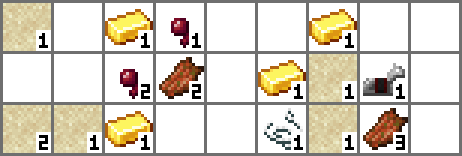

In [42]:
visualize(loot, scale=3)

In [ ]:
from loot import loottable_c

shuffle_order = 0
for i in range(27):
    shuffle_order |= ((loot[i] is not None) << i)
print(f"uint32_t shuffle_order = 0b{bin(shuffle_order)[2:].zfill(27)};")
loottable,lookup = loottable_c(table, loot_item_counts)
#print(f"int64_t seed = {feature_seed};")
print(f"uint8_t table[{len(loottable)}] = {'{'}{str(loottable)[1:-1]}{'}'};")
targ = [0]*len(lookup)
for item,qty in loot_item_counts.items(): targ[lookup[item]] = qty
print(f"uint8_t target[{len(targ)}] = {'{'}{str(targ)[1:-1]}{'}'};")
print(f"int distinct_items = {len(lookup)};")

uint32_t shuffle_order = 0b011100111011101100001001101;
int64_t seed = 251488402217879;
uint8_t table[1140] = {2, 0, 0, 0, 2, 4, 232, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 1, 1, 5, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 2, 2, 7, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 1, 3, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0, 1, 4, 6, 0,

In [44]:
def desert_pyramid_can_gen(wseed,cx,cz):
    spacing=32
    separation=8
    salt=14357617
    rx,rz=cx//spacing,cz//spacing
    r=JavaRandom(wseed+rx*341873128712+rz*132897987541+salt)
    return r.nextInt(spacing-separation)==(cx%spacing) and r.nextInt(spacing-separation)==(cz%spacing)
def treasure_can_gen(wseed,cx,cz):
    salt=10387320
    r=JavaRandom(wseed+cx*341873128712+cz*132897987541+salt)
    return r.nextFloat() < 0.01

######### From WorldGenRandom.class #########
def setBaseChunkSeed(integer1, integer2):
    long4 = integer1 * 341873128712 + integer2 * 132897987541
    return long4

def setDecorationSeed(long1, integer2, integer3):#population
    r=JavaRandom(long1)
    long6 = r.nextLong() | 0x1
    long8 = r.nextLong() | 0x1
    long10 = integer2 * long6 + integer3 * long8 ^ long1
    return long10&((1<<48)-1)

def setFeatureSeed(long1, integer2, integer3):#decoration
    long6 = long1 + integer2 + (10000 * integer3)
    return long6

def setLargeFeatureSeed(long1, integer2, integer3):
    r=JavaRandom(long1)
    long6 = r.nextLong()
    long8 = r.nextLong()
    long10 = integer2 * long6 ^ integer3 * long8 ^ long1
    return long10

def setLargeFeatureWithSalt(long1, integer2, integer3, integer4):
    long7 = integer2 * 341873128712 + integer3 * 132897987541 + long1 + integer4
    return long7
######### End #########


def btloot(wseed,cx,cz):
    index,step=salts['bt']
    loot_seed=JavaRandom(setFeatureSeed(setDecorationSeed(wseed,cx<<4,cz<<4),index,step)).nextLong()
    return loot(loot_seed,bt)

def dtlootseed(wseed,cx,cz,i):
    index,step=salts['des']
    r=JavaRandom(setFeatureSeed(setDecorationSeed(wseed,cx<<4,cz<<4),index,step))
    for j in range(i):r.nextLong()
    return r.nextLong()